# Frame Overlap: Analyzing Neutron Time-of-Flight Data

This tutorial demonstrates how to use the `frame_overlap` Python package to analyze neutron Time-of-Flight (ToF) data. The package provides tools for data preparation, kernel generation, Wiener deconvolution, parameter optimization, and visualization.

In [1]:
# import os
# os.system('ls ../../')

In [1]:
# Installation (uncomment if needed)
%pip install -e ../../frame_overlap/
# !pip install git+https://github.com/TsvikiHirsh/nbragg.git
# !pip install ../../frame_overlap/

Obtaining file:///media/ExtHDD02/nuclear/frame_overlap
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Cloning https://github.com/XuShuqi7/ncplugin-CrysExtn to /tmp/pip-install-8v9fbrjn/ncrystal-plugin-crysextn_12ef9445d89d4ceb8cd773deb8611923
  Running command git clone --filter=blob:none --quiet https://github.com/XuShuqi7/ncplugin-CrysExtn /tmp/pip-install-8v9fbrjn/ncrystal-plugin-crysextn_12ef9445d89d4ceb8cd773deb8611923
  Resolved https://github.com/XuShuqi7/ncplugin-CrysExtn to commit ae714053206d4356f3bbd7485c3dcaaf1a16c8bb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Building editable for frame_overlap (pyproject.toml) ... done
  Created wheel for frame_overlap: filename=frame_overlap-0.1.0-0.editable-py3-none-any.whl size=2338 

In [ ]:
# import os
# os.system('ls ../src/frame_overlap')

analysis.py
data.py
__init__.py
optimization.py
visualization.py


0

In [2]:
# import sys
# sys.path.append('../src/frame_overlap')
from frame_overlap import (
    read_tof_data,
    prepare_full_frame,
    generate_kernel,
    apply_filter,
    chi2_analysis,
    plot_analysis,
    optimize_parameters
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import concurrent.futures
import nbragg
import lmfit
from lmfit.model import save_modelresult
from concurrent.futures import ThreadPoolExecutor, as_completed
from itertools import product


## Loading and Preparing Data

### Predefined Values

In [3]:
nbragg.register_material("Fe_sg229_Iron-alpha_CrysExtn1.ncmat")
nbragg.register_material("Cellulose_C6O5H10.ncmat")

xs0 = 0.0275 * nbragg.CrossSection(cellulose=nbragg.materials["Cellulose_C6O5H10.ncmat"]) + \
     (1 - 0.0275) * nbragg.CrossSection(α=nbragg.materials["Fe_sg229_Iron-alpha_CrysExtn1.ncmat"])
xs0.materials['α']["ext_method"] = "Sabine_uncorr"
xs0.materials['α']["ext_tilt"] = "tri"
xs0 = nbragg.CrossSection(xs0.materials)

xs1 = 0.0275 * nbragg.CrossSection(cellulose=nbragg.materials["Cellulose_C6O5H10.ncmat"]) + \
     (1 - 0.0275) * nbragg.CrossSection(α=nbragg.materials["Fe_sg229_Iron-alpha_CrysExtn1.ncmat"])
xs1.materials['α']["ext_method"] = "Sabine_uncorr"
xs1.materials['α']["ext_tilt"] = "rect"
xs1 = nbragg.CrossSection(xs1.materials)

xs2 = 0.0275 * nbragg.CrossSection(cellulose=nbragg.materials["Cellulose_C6O5H10.ncmat"]) + \
     (1 - 0.0275) * nbragg.CrossSection(α=nbragg.materials["Fe_sg229_Iron-alpha_CrysExtn1.ncmat"])
xs2.materials['α']["ext_method"] = "Sabine_corr"
xs2 = nbragg.CrossSection(xs2.materials)

xs3 = 0.0275 * nbragg.CrossSection(cellulose=nbragg.materials["Cellulose_C6O5H10.ncmat"]) + \
     (1 - 0.0275) * nbragg.CrossSection(α=nbragg.materials["Fe_sg229_Iron-alpha_CrysExtn1.ncmat"])
xs3.materials['α']["ext_method"] = "Sabine_corr"
xs3 = nbragg.CrossSection(xs3.materials)

xs4 = 0.0275 * nbragg.CrossSection(cellulose=nbragg.materials["Cellulose_C6O5H10.ncmat"]) + \
     (1 - 0.0275) * nbragg.CrossSection(α=nbragg.materials["Fe_sg229_Iron-alpha_CrysExtn1.ncmat"])
xs4.materials['α']["ext_method"] = "BC_mix"
xs4 = nbragg.CrossSection(xs4.materials)

xs5 = 0.0275 * nbragg.CrossSection(cellulose=nbragg.materials["Cellulose_C6O5H10.ncmat"]) + \
     (1 - 0.0275) * nbragg.CrossSection(α=nbragg.materials["Fe_sg229_Iron-alpha_CrysExtn1.ncmat"])
xs5.materials['α']["ext_method"] = "CR"
xs5 = nbragg.CrossSection(xs5.materials)

# model = nbragg.TransmissionModel(xs, vary_extinction=True,vary_background=True,vary_weights=True,vary_response=True)
# model = nbragg.TransmissionModel(xs, vary_extinction=True,vary_weights=True,vary_response=True)

groups0 = {
    "basic": ["norm"],
    "thickness": ["thickness"],
    "extinction": ["ext_Gg2", "ext_L2"],
    "bg": ["background"],
    "weights": ["weights"],
    "response": ["response"]    
}

groups1 = {
    "basic": ["norm"],
    "bg": ["background"],
    "extinction": ["ext_Gg2", "ext_L2"],
    "thickness": ["thickness"],
    "weights": ["weights"],
    "response": ["response"]    
}

groups2 = {
    "basic": ["norm","thickness"],
    "bg": ["background"],
    "Advanced": ["ext_Gg2", "ext_L2","weights","response"]   
}

groups3 = {
    "basic": ["norm","thickness","wlmin=3","wlmax=6"],
    "bg": ["background","wlmin=3","wlmax=5"],
    "Advanced": ["ext_Gg2", "ext_L2","weights","response","wlmin=2","wlmax=4.2"]   
}

groups4 = {
    "basic": ["norm","thickness","wlmin=4","wlmax=6"],
    "bg": ["background","wlmin=3","wlmax=5"],
    "Advanced": ["ext_Gg2", "ext_L2","weights","response","wlmin=1","wlmax=3"]   
}

xs_dict = {
    'xs0': xs0,
    'xs1': xs1,
    'xs2': xs2, 
    'xs3': xs3,
    'xs4': xs4,
    'xs5': xs5
}
groups_dict = {
    'None': None,
    'groups0': groups0,
    'groups1': groups1,
    'groups2': groups2,
    'groups3': groups3,
    'groups4': groups4
}

t_signal, signal, errors, stacks = read_tof_data('iron_powder.csv')
t_signal_ob, signal_ob, errors_ob, stacks_ob = read_tof_data('openbeam.csv')

stacks1, signal1, errors1 = prepare_full_frame(t_signal, signal, errors, stacks, max_stack=5000)
stacks_ob1, signal_ob1, errors_ob1 = prepare_full_frame(t_signal_ob, signal_ob, errors_ob, stacks_ob, max_stack=5000)

### Functions

In [4]:
def scale_time(n_pulses=50, pulse_duration=20, frequency=64, saraf_irad_time=12):
    return (1e6/5e6) * (saraf_irad_time/0.5) * (frequency*n_pulses*pulse_duration*1e-6)

def chi2_like_analysis(scaled_original, reconstructed, errors, DOF):
    """
    Calculate chi-squared and reduced chi-squared statistics for model fit evaluation.

    Parameters
    ----------
    scaled_original : array-like
        The scaled original signal data.
    reconstructed : array-like
        The reconstructed signal data from the model.
    errors : array-like
        The uncertainties associated with the scaled original signal.
    DOF : int
        Number of degrees of freedom associated with the fit.

    Returns
    -------
    tuple
        A tuple containing:
        - chi2 : float, the chi-squared statistic
        - chi2_per_dof : float, the reduced chi-squared (chi2 per degree of freedom)

    Raises
    ------
    ValueError
        If inputs have inconsistent shapes or contain invalid values (e.g., zero or negative errors).
    TypeError
        If inputs are not array-like or contain non-numeric values.

    Examples
    --------
    >>> import numpy as np
    >>> scaled = np.array([1.0, 2.0, 3.0])
    >>> recon = np.array([1.1, 2.1, 2.9])
    >>> errs = np.array([0.1, 0.1, 0.1])
    >>> chi2, chi2_dof = chi2_analysis(scaled, recon, errs)
    >>> print(f"Chi2: {chi2:.2f}, Reduced Chi2: {chi2_dof:.2f}")
    """
    # Input validation
    scaled_original = np.asarray(scaled_original, dtype=float)
    reconstructed = np.asarray(reconstructed, dtype=float)
    errors = np.asarray(errors, dtype=float)
    
    if scaled_original.shape != reconstructed.shape or scaled_original.shape != errors.shape:
        raise ValueError("All input arrays must have the same shape")
    if np.any(errors <= 0):
        raise ValueError("Errors must be positive")
    if np.any(np.isnan(scaled_original)) or np.any(np.isnan(reconstructed)) or np.any(np.isnan(errors)):
        raise ValueError("Input arrays must not contain NaN values")

    residuals = scaled_original - reconstructed
    chi2 = np.sum((residuals / errors)**2)
    chi2_per_dof = chi2 / (len(scaled_original)-DOF)
    # print(c)
    return chi2, chi2_per_dof

def chi2_like_analysis1(scaled_original, reconstructed, errors, window_size, DOF):
    """
    Calculate chi-squared and reduced chi-squared statistics for model fit evaluation.

    Parameters
    ----------
    scaled_original : array-like
        The scaled original signal data.
    reconstructed : array-like
        The reconstructed signal data from the model.
    errors : array-like
        The uncertainties associated with the scaled original signal.
    DOF : int
        Number of degrees of freedom associated with the fit.

    Returns
    -------
    tuple
        A tuple containing:
        - chi2 : float, the chi-squared statistic
        - chi2_per_dof : float, the reduced chi-squared (chi2 per degree of freedom)

    Raises
    ------
    ValueError
        If inputs have inconsistent shapes or contain invalid values (e.g., zero or negative errors).
    TypeError
        If inputs are not array-like or contain non-numeric values.

    Examples
    --------
    >>> import numpy as np
    >>> scaled = np.array([1.0, 2.0, 3.0])
    >>> recon = np.array([1.1, 2.1, 2.9])
    >>> errs = np.array([0.1, 0.1, 0.1])
    >>> chi2, chi2_dof = chi2_analysis(scaled, recon, errs)
    >>> print(f"Chi2: {chi2:.2f}, Reduced Chi2: {chi2_dof:.2f}")
    """
    # Input validation
    scaled_original = np.asarray(scaled_original[:window_size], dtype=float)
    reconstructed = np.asarray(reconstructed[:window_size], dtype=float)
    errors = np.asarray(errors[:window_size], dtype=float)
    
    if scaled_original.shape != reconstructed.shape or scaled_original.shape != errors.shape:
        raise ValueError("All input arrays must have the same shape")
    if np.any(errors <= 0):
        raise ValueError("Errors must be positive")
    if np.any(np.isnan(scaled_original)) or np.any(np.isnan(reconstructed)) or np.any(np.isnan(errors)):
        raise ValueError("Input arrays must not contain NaN values")

    residuals = scaled_original - reconstructed
    chi2 = np.sum((residuals / errors)**2)
    chi2_per_dof = chi2 / (len(scaled_original)-DOF)
    # print(c)
    return chi2, chi2_per_dof

def run_single(scaled_signal,window_size,n_pulses,pulse_duration,returns):
    chi_sqr1 = []
    chi_sqr2 = []
    # chi_sqr3 = []
    for i in range(returns):
        # print(i)
        t_kernel, kernel = generate_kernel(n_pulses=n_pulses, pulse_duration=pulse_duration, window_size=window_size)
        # print(kernel)
        observed_poisson, reconstructed = apply_filter(
            scaled_signal,
            kernel,
            # stats_fraction=1,
            noise_power=0.05
        )
        chi22, chi2_per_dof2 = chi2_like_analysis1(
            scaled_signal,
            reconstructed,
            np.sqrt(scaled_signal),
            1100,
            n_pulses
        )
        chi_sqr2.append(chi2_per_dof2)
    return np.mean(chi_sqr2), np.var(chi_sqr2)
# Pay attention that the time is set to a constant - 5

def process_iteration(j, k, i, l):
    try:
        # Trying to optimize parameters, increase the frequency to 64 which is equivalent to maximal window size of 15625 us
        # increase the irradiation time to 12 hours as well.
        scaled_signal = signal * scale_time(scale_time(n_pulses=j,pulse_duration=k,frequency=80,saraf_irad_time=24))
        a, b = run_single(scaled_signal, i, j, k, l)  # num of returns
    except:
        a, b = 0, 0
    return dict(window_size=i, n_pulses=j, pulse_duration=k, ave_fact=l, chisqr=a, var_chisqr=b)

def write_data(stack,signal,error,filepath=''):
    df=pd.DataFrame()
    df['stack']=stack
    signal[signal<0]=np.nan
    df['signal']=np.round(signal,3)
    # error[error==np.isnan(error)]=np.nan
    df['error']=np.round(error,3)
    df.to_csv(filepath,sep=',')

def write_data_df(stack,signal,error):
    df=pd.DataFrame()
    df['stack']=stack
    signal[signal<0]=np.nan
    df['signal']=np.round(signal,3)
    # error[error==np.isnan(error)]=np.nan
    df['error']=np.round(error,3)
    # df.to_csv(filepath,sep=',')
    return df

def read_and_stack(filename,stack_time=50000,threshold=40):
    t_signal, signal, errors, stacks = read_tof_data(filename, threshold=threshold)
    len_d = int((stack_time-10-t_signal.iloc[-1])/10-1)# here we're assuming measuring in steps of 10us. 
    zeros_to_stack = np.zeros(len_d, dtype=int) 
    stack_to_stack = np.arange(stacks[-1]+1,int(stack_time/10))
    signal = np.hstack((signal, zeros_to_stack))
    errors = np.hstack((errors, zeros_to_stack))
    stacks1 = np.append(stacks,stack_to_stack)
    zero_df = pd.Series(stack_to_stack*10)
    t_signal = pd.concat([t_signal, zero_df], ignore_index=True)
    return t_signal, signal, errors, stacks1

def generate_simple_kernel(n_pulses, window_size=5000, bin_width=10, pulse_duration=200, pulse_height=1.0):
    """
    Generate a kernel with non-overlapping rectangular pulses for signal convolution.

    Parameters
    ----------
    n_pulses : int
        Number of pulses in the kernel.
    window_size : int, optional
        Total size of the kernel window in microseconds (default: 5000).
    bin_width : float, optional
        Width of each time bin in microseconds (default: 10).
    pulse_duration : float, optional
        Duration of each pulse in microseconds (default: 200).
    pulse_height : float, optional
        Amplitude of each pulse (default: 1.0).

    Returns
    -------
    tuple
        A tuple containing:
        - t_kernel : array-like, time array for the kernel
        - kernel : array-like, kernel array with rectangular pulses

    Raises
    ------
    ValueError
        If parameters are invalid (e.g., negative values, insufficient window size).
    TypeError
        If inputs are not of expected numeric types.

    Examples
    --------
    >>> import numpy as np
    >>> t, k = generate_kernel(n_pulses=3, window_size=1000, bin_width=10, pulse_duration=100)
    >>> t.shape == k.shape
    True
    >>> np.sum(k) > 0
    True
    """
    # Input validation
    if not isinstance(n_pulses, int) or n_pulses < 1:
        raise ValueError("n_pulses must be a positive integer")
    if window_size <= 0 or bin_width <= 0 or pulse_duration <= 0 or pulse_height < 0:
        raise ValueError("window_size, bin_width, pulse_duration must be positive; pulse_height must be non-negative")
    
    t_kernel = np.arange(0, window_size, bin_width, dtype=float)
    kernel = np.zeros_like(t_kernel, dtype=float)
    
    pulse_length = int(pulse_duration / bin_width)
    total_pulse_space = n_pulses * pulse_length
    
    if total_pulse_space > len(t_kernel):
        raise ValueError(f"Total pulse space ({total_pulse_space * bin_width} µs) exceeds window size ({window_size} µs)")
    
    start_indices = []
    
    for _ in range(n_pulses):
        start_idx = int(window_size/n_pulses*_)
        start_indices.append(start_idx)
            
    for start_idx in start_indices:
        kernel[start_idx:start_idx + pulse_length] = pulse_height
    
    return t_kernel, kernel

def construct_data(signal,signal_ob,n_pulses=5,pulse_duration=100,bin_width=10,filter_type='simple'):
    saraf_irad_time = 24 # time in hours
    frequency = 20 # frequency in herz
    n_pulses = n_pulses # number of pulses
    pulse_duration = pulse_duration # pulse duration in usec
    window_size=int(len(signal)*bin_width)  
    # print(window_size)  
    scaling_factor = (1e6/5e6) * (saraf_irad_time/0.5) * (frequency*n_pulses*pulse_duration*1e-6)
    scaled_signal = signal * scaling_factor
    scaled_ob = signal_ob * scaling_factor
    # if filter_type == 'simple':
    t_kernel, kernel = generate_kernel(n_pulses=n_pulses, pulse_duration=pulse_duration, window_size=window_size, method=filter_type)
    # elif filter_type == 'complex':
        # t_kernel, kernel = generate_kernel(n_pulses=n_pulses, pulse_duration=pulse_duration, window_size=window_size)
    
    # Apply Wiener deconvolution to the signal
    observed_poisson, reconstructed = apply_filter(
        scaled_signal,
        kernel,
        # stats_fraction=1,
        noise_power=0.005
    )
    # Apply Wiener deconvolution to the signal
    observed_poisson_ob, reconstructed_ob = apply_filter(
        scaled_ob,
        kernel,
        # stats_fraction=1,
        noise_power=0.005
    )
    # plt.plot(kernel)
    return reconstructed, reconstructed_ob, kernel

# def run_nbragg(n_start=50, pulse_width=30, xs=xs0, filter_type='single', groups=groups0, modified=True):
#     if modified:
#         reconstructed, reconstructed_ob = construct_data(signal1,signal_ob1,n_start,pulse_width,filter_type=filter_type)
#         iron_powder1=write_data_df(stacks1,reconstructed,np.sqrt(reconstructed))
#         openbeam1=write_data_df(stacks_ob1,reconstructed_ob,np.sqrt(reconstructed_ob))
#         data = nbragg.Data.from_counts(iron_powder1, openbeam1)
#     else:
#         data = nbragg.Data.from_counts("iron_powder.csv", "openbeam.csv")
#     data.table = data.table.dropna()
#     model = nbragg.TransmissionModel(xs, vary_extinction=True,vary_background=True,vary_weights=True,vary_response=True)

#     if groups==None:
#         result = model.fit()
#     else:
#         result = model.fit(
#             data,
#             method="rietveld",
#             param_groups=groups,
#             # progress_bar=True
#         )
#     return result.redchi

# from lmfit.model import save_modelresult
# import numpy as np

def run_nbragg(n_start=50, pulse_width=30, xs=xs0, filter_type='single', groups=groups0, modified=True):
    if modified:
        reconstructed, reconstructed_ob, kernel = construct_data(signal1, signal_ob1, n_start, pulse_width, filter_type=filter_type)
        iron_powder1 = write_data_df(stacks1, reconstructed, np.sqrt(reconstructed))
        openbeam1 = write_data_df(stacks_ob1, reconstructed_ob, np.sqrt(reconstructed_ob))
        data = nbragg.Data.from_counts(iron_powder1, openbeam1)
    else:
        data = nbragg.Data.from_counts("iron_powder.csv", "openbeam.csv")
    
    data.table = data.table.dropna()
    model = nbragg.TransmissionModel(
        xs,
        vary_extinction=True,
        vary_background=True,
        vary_weights=True,
        vary_response=True
    )

    if groups is None:
        result = model.fit(data)
    else:
        result = model.fit(data, method="rietveld", param_groups=groups)
    # minimizer_result = result.minimizer
    # Force calculation of uncertainties (covariance matrix)
    # ci = lmfit.conf_interval(result.minimizer, result)
    # result.calc_covar()

    # Extract initial and final parameters
    # n_indexes = {get_first_one_indices(kernel)}
    initial_params = {k: v.value for k, v in result.init_params.items()}
    final_params = {k: v.value for k, v in result.params.items()}
    uncertainties = {k: v.stderr for k, v in result.params.items()}

    return {
        'n_indexes': get_first_one_indices(kernel),
        'pulse_width': pulse_width,
        'initial_params': initial_params,
        'final_params': final_params,
        'uncertainties': uncertainties,
        'redchi': result.redchi,
        'success': result.success,
    }
    # return result



def run_with_context(n_start, pulse_width, xs_name, groups_name, modified,filter_type):
    # pref_to_find1 = "groups"
    # group_names = example_function(pref_to_find1)
    # # group_names = find_variables_by_prefix(pref_to_find1, locals())
    # pref_to_find2 = "xs"
    # xs_names = find_variables_by_prefix(pref_to_find2, locals())
    xs = xs_dict[xs_name]  # Retrieve the object from xs_dict using the name
    groups = groups_dict[groups_name]
    
    try:
        result = run_nbragg(n_start=n_start, pulse_width=pulse_width, xs=xs, groups=groups, modified=modified,filter_type=filter_type)
        # uncertainties_dict = {name: param.stderr for name, param in result.params.items() if param.stderr is not None}
        # print('result values',result.params.valuesdict())
        # print('uncertainty values',uncertainties_dict)
        return {
            # 'n_start': n_start,
            # 'pulse_width': pulse_width,
            'xs': xs_name,     # You may need a way to stringify your xs/group objects
            'groups': groups_name,
            'filter_type': filter_type,
            **result
            # 'params': result.params.valuesdict(),
            # 'uncertainties': uncertainties_dict,
            # 'redchi': result.redchi,
            # 'success': result.success
        }
    except Exception as e:
        return {
            # 'n_start': n_start,
            # 'pulse_width': pulse_width,
            'xs': xs_name,
            'groups': groups_name,
            'filter_type': filter_type,
            'error': str(e)
        }
    
def find_variables_by_prefix(prefix, scope):
    """
    Finds variable names in a given scope that start with a specified prefix.

    Args:
        prefix (str): The string prefix to search for.
        scope (dict): The dictionary representing the scope (e.g., globals() or locals()).

    Returns:
        list: A list of variable names that start with the prefix.
    """
    matching_variables = []
    for name in scope.keys():
        if name.startswith(prefix):
            matching_variables.append(name)
    return matching_variables

def example_function(prefix='xs'):
    # local_variable = name
    for name in locals().items():
        print(name)
        # if name.startswith(prefix):
            # print(f"Found variable: {name}")
        # if value is local_variable:
        #     print(f"The name of the variable is: {name}")
        #     break
    return name
# example_function()

import numpy as np

def get_first_one_indices(mask_array):
    """
    Extracts the indices of the first '1' in each continuous occurrence of '1's.

    Args:
        mask_array (np.ndarray): A 1D NumPy array of zeros and ones.

    Returns:
        list: A list containing the indices of the first '1' in each occurrence.
    """
    first_one_indices = []
    # Convert to a boolean array for easier comparison
    boolean_mask = mask_array == 1

    # Iterate through the array to find the start of '1' sequences
    for i in range(len(boolean_mask)):
        if boolean_mask[i]:  # If the current element is '1'
            # Check if it's the first '1' of an occurrence
            # This is true if it's the very first element, or if the previous element was '0'
            if i == 0 or not boolean_mask[i-1]:
                first_one_indices.append(i)
    return first_one_indices

# Example Usage:
# mask = np.array([0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1])
# indices = get_first_one_indices(mask)
# print(f"Original mask array: {mask}")
# print(f"Indices of the first '1' in each occurrence: {indices}")
# indices

In [27]:
# Define your xs and groups lists
# xs_dict = {
#     'xs0': xs0,
#     'xs1': xs1,
#     'xs2': xs2, 
#     'xs3': xs3,
#     'xs4': xs4,
#     'xs5': xs5
# }
# group_dict = {
#     'None': None,
#     'groups0': groups0,
#     'groups1': groups1,
#     'groups2': groups2,
#     'groups3': groups3,
#     'groups4': groups4
# }

xs_list0 = ['xs0', 'xs2', 'xs4']
groups_list0 = ['groups0', 'groups2', 'groups3']

# Generate all combinations of parameters
n_start_range = [10]#range(10, 20, 20)
pulse_width_range = [10]#range(10, 20, 20)
modified = [False]
param_combinations = list(product(n_start_range, pulse_width_range, xs_list0, groups_list0, modified))
param_combinations[5:15]

# Define a wrapper to run the function and return full context
# param_combinations[0]
# len(param_combinations)
# Run in parallel
# results = []
# result = run_nbragg(n_start=10, pulse_width=10, xs=xs0, groups=groups3, modified=False)
# for (n_start, pulse_width, xs, groups) in param_combinations:
#     result = run_with_context(n_start, pulse_width, xs, groups)
#     results.append(result)

# with ThreadPoolExecutor(max_workers=25) as executor:  # Adjust max_workers to your system
#     futures = [
#         executor.submit(run_with_context, n_start, pulse_width, xs, groups, modified)
#         for (n_start, pulse_width, xs, groups, modified) in param_combinations
#     ]
    
#     for future in as_completed(futures):
#         result = future.result()
#         results.append(result)

# df = pd.DataFrame(results)
# df.to_csv('fit_results_original_data.csv', index=False)
# del df

[(10, 10, 'xs2', 'groups3', False),
 (10, 10, 'xs4', 'groups0', False),
 (10, 10, 'xs4', 'groups2', False),
 (10, 10, 'xs4', 'groups3', False)]

In [29]:
print(result.fit_report())
# result.conf_interval()

[[Model]]
    Model(transmission)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 372
    # data points      = 500
    # variables        = 10
    chi-square         = 4952.32592
    reduced chi-square = 10.1067876
    Akaike info crit   = 1166.50226
    Bayesian info crit = 1208.64835
    R-squared          = 0.99069857
[[Variables]]
    thickness:  2.02985745 +/- 0.04491168 (2.21%) (init = 2.77916)
    norm:       0.80670343 +/- 0.05011133 (6.21%) (init = 1.836232)
    temp:       300 (fixed)
    p1:        -13.9999744 +/- 6871.62274 (49083.11%) (init = -3.565684)
    cellulose:  8.3155e-07 +/- 0.00571409 (687161.70%) == 'exp(p1) / (1 + exp(p1))'
    α:          0.99999917 +/- 0.00571220 (0.57%) == '1 / (1 + exp(p1))'
    ext_l2:     0 (fixed)
    ext_Gg2:    623.042298 +/- 1.4328e+08 (22997493.59%) (init = 1000)
    ext_L2:     66228.3634 +/- 1.5247e+10 (23022095.23%) (init = 100000)
    α0:         4.45846546 +/- 0.27133567 (6.09%) (init = 3.67)
    β0:

In [5]:
# Define your xs and groups lists
xs_list1 = ['xs0']
groups_list1 = ['groups0']

# Generate all combinations of parameters
n_start_range = range(10, 4000, 10)
pulse_width_range = range(10, 1000, 10)
modified = [True]
param_combinations = list(product(n_start_range, pulse_width_range, xs_list1, groups_list1, modified))

population_range = range(len(param_combinations))  # Represents numbers from 1 to len(param_combinations)
num_elements_to_choose = 50

# Randomly select the indices
random_elements = np.random.choice(population_range, num_elements_to_choose, replace=False)

# Create the mask
mask = np.zeros(len(param_combinations), dtype=bool)
mask[random_elements] = True

# Apply the mask to the param_combinations list
# param_combinations1 = np.array(param_combinations)[mask]
param_combinations1 = [param_combinations[i] for i in range(len(param_combinations)) if mask[i]]

# Now param_combinations1 contains the randomly selected masked combinations
# print(len(param_combinations1))
# param_combinations1[10:15]

# Define a wrapper to run the function and return full context
# param_combinations[0]
# len(param_combinations)
# Run in parallel
results = []

# # for (n_start, pulse_width, xs, groups) in param_combinations:
# #     result = run_with_context(n_start, pulse_width, xs, groups)
# #     results.append(result)

with ThreadPoolExecutor(max_workers=25) as executor:  # Adjust max_workers to your system
    futures = [
        executor.submit(run_with_context, n_start, pulse_width, xs, groups, modified)
        for (n_start, pulse_width, xs, groups, modified) in param_combinations1
    ]
    
    for future in as_completed(futures):
        result = future.result()
        results.append(result)

df = pd.DataFrame(results)
df.to_csv('fit_results_24hrs_saraf_xs0_groups0.csv', index=False)
del df

/tmp/ipykernel_1598018/263087884.py:308: RuntimeWarning: invalid value encountered in sqrt
  iron_powder1 = write_data_df(stacks1, reconstructed, np.sqrt(reconstructed))
/tmp/ipykernel_1598018/263087884.py:308: RuntimeWarning: invalid value encountered in sqrt
  iron_powder1 = write_data_df(stacks1, reconstructed, np.sqrt(reconstructed))
/tmp/ipykernel_1598018/263087884.py:308: RuntimeWarning: invalid value encountered in sqrt
  iron_powder1 = write_data_df(stacks1, reconstructed, np.sqrt(reconstructed))
/tmp/ipykernel_1598018/263087884.py:309: RuntimeWarning: invalid value encountered in sqrt
  openbeam1 = write_data_df(stacks_ob1, reconstructed_ob, np.sqrt(reconstructed_ob))
/tmp/ipykernel_1598018/263087884.py:309: RuntimeWarning: invalid value encountered in sqrt
  openbeam1 = write_data_df(stacks_ob1, reconstructed_ob, np.sqrt(reconstructed_ob))
/tmp/ipykernel_1598018/263087884.py:308: RuntimeWarning: invalid value encountered in sqrt
  iron_powder1 = write_data_df(stacks1, reconst

Rietveld Fit:   0%|          | 0/6 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/6 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/6 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/6 [00:00<?, ?it/s]

...

Rietveld Fit:   0%|          | 0/6 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/6 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/6 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/6 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/6 [00:00<?, ?it/s]

In [6]:
# Define your xs and groups lists
xs_list1 = ['xs0']
groups_list1 = ['None']

# Generate all combinations of parameters
n_start_range = range(10, 4000, 10)
pulse_width_range = range(10, 1000, 10)
modified = [True]
param_combinations = list(product(n_start_range, pulse_width_range, xs_list1, groups_list1, modified))

population_range = range(len(param_combinations))  # Represents numbers from 1 to len(param_combinations)
num_elements_to_choose = 50

# Randomly select the indices
random_elements = np.random.choice(population_range, num_elements_to_choose, replace=False)

# Create the mask
mask = np.zeros(len(param_combinations), dtype=bool)
mask[random_elements] = True

# Apply the mask to the param_combinations list
# param_combinations1 = np.array(param_combinations)[mask]
param_combinations1 = [param_combinations[i] for i in range(len(param_combinations)) if mask[i]]

# param_combinations1 = param_combinations[mask]
# print(a)
# len(param_combinations1)
# Define a wrapper to run the function and return full context
# param_combinations[0]
# len(param_combinations)
# Run in parallel
results = []

# for (n_start, pulse_width, xs, groups) in param_combinations:
#     result = run_with_context(n_start, pulse_width, xs, groups)
#     results.append(result)

with ThreadPoolExecutor(max_workers=25) as executor:  # Adjust max_workers to your system
    futures = [
        executor.submit(run_with_context, n_start, pulse_width, xs, groups, modified)
        for (n_start, pulse_width, xs, groups, modified) in param_combinations1
    ]
    
    for future in as_completed(futures):
        result = future.result()
        results.append(result)

df = pd.DataFrame(results)
df.to_csv('fit_results_24hrs_saraf_xs0_None.csv', index=False)
del df

Fitting:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting:   0%|          | 0/1 [00:00<?, ?it/s]

...

Fitting:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting:   0%|          | 0/1 [00:00<?, ?it/s]

Fitting:   0%|          | 0/1 [00:00<?, ?it/s]

In [11]:
# Define your xs and groups lists
xs_list2 = ['xs0']
groups_list2 = ['groups2']

# Generate all combinations of parameters
n_start_range = range(10, 4000, 10)
pulse_width_range = range(10, 1000, 10)
modified = [True]
param_combinations = list(product(n_start_range, pulse_width_range, xs_list2, groups_list2, modified))

population_range = range(len(param_combinations))  # Represents numbers from 1 to len(param_combinations)
num_elements_to_choose = 50

# Randomly select the indices
random_elements = np.random.choice(population_range, num_elements_to_choose, replace=False)

# Create the mask
mask = np.zeros(len(param_combinations), dtype=bool)
mask[random_elements] = True

# Apply the mask to the param_combinations list
# param_combinations1 = np.array(param_combinations)[mask]
param_combinations2 = [param_combinations[i] for i in range(len(param_combinations)) if mask[i]]
# param_combinations1 = param_combinations[mask==1]
# print(a)

# Define a wrapper to run the function and return full context
# param_combinations[0]
# len(param_combinations)
# Run in parallel
results = []


with ThreadPoolExecutor(max_workers=25) as executor:  # Adjust max_workers to your system
    futures = [
        executor.submit(run_with_context, n_start, pulse_width, xs, groups, modified)
        for (n_start, pulse_width, xs, groups, modified) in param_combinations2
    ]
    
    for future in as_completed(futures):
        result = future.result()
        results.append(result)

df = pd.DataFrame(results)
df.to_csv('fit_results_24hrs_saraf_xs0_groups2.csv', index=False)
del df

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

...

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
# Define your xs and groups lists
xs_list3 = ['xs0']
groups_list3 = ['groups3']

# Generate all combinations of parameters
n_start_range = range(10, 4000, 10)
pulse_width_range = range(10, 1000, 10)
modified = [True]
param_combinations = list(product(n_start_range, pulse_width_range, xs_list3, groups_list3, modified))

population_range = range(len(param_combinations))  # Represents numbers from 1 to len(param_combinations)
num_elements_to_choose = 50

# Randomly select the indices
random_elements = np.random.choice(population_range, num_elements_to_choose, replace=False)

# Create the mask
mask = np.zeros(len(param_combinations), dtype=bool)
mask[random_elements] = True

# Apply the mask to the param_combinations list
# param_combinations1 = np.array(param_combinations)[mask]
param_combinations3 = [param_combinations[i] for i in range(len(param_combinations)) if mask[i]]
# print(a)

# Define a wrapper to run the function and return full context
# param_combinations[0]
# len(param_combinations)
# Run in parallel
results = []

# for (n_start, pulse_width, xs, groups) in param_combinations:
#     result = run_with_context(n_start, pulse_width, xs, groups)
#     results.append(result)

with ThreadPoolExecutor(max_workers=25) as executor:  # Adjust max_workers to your system
    futures = [
        executor.submit(run_with_context, n_start, pulse_width, xs, groups, modified)
        for (n_start, pulse_width, xs, groups, modified) in param_combinations3
    ]
    
    for future in as_completed(futures):
        result = future.result()
        results.append(result)

df = pd.DataFrame(results)
df.to_csv('fit_results_24hrs_saraf_xs0_groups3.csv', index=False)
del df

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

...

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

In [13]:
# Define your xs and groups lists
xs_list5 = ['xs0']
groups_list5 = ['groups3']

# Generate all combinations of parameters
n_start_range = range(10, 4000, 10)
pulse_width_range = range(10, 1000, 10)
modified = [True]
filter_type = ['single']
param_combinations = list(product(n_start_range, pulse_width_range, xs_list5, groups_list5, modified, filter_type))

population_range = range(len(param_combinations))  # Represents numbers from 1 to len(param_combinations)
num_elements_to_choose = 1000

# Randomly select the indices
random_elements = np.random.choice(population_range, num_elements_to_choose, replace=False)

# Create the mask
mask = np.zeros(len(param_combinations), dtype=bool)
mask[random_elements] = True

# Apply the mask to the param_combinations list
# param_combinations1 = np.array(param_combinations)[mask]
param_combinations5 = [param_combinations[i] for i in range(len(param_combinations)) if mask[i]]

# Now param_combinations1 contains the randomly selected masked combinations
# print(len(param_combinations1))
# param_combinations1[10:15]

# Define a wrapper to run the function and return full context
# param_combinations[0]
# len(param_combinations)
# Run in parallel
results = []

# # for (n_start, pulse_width, xs, groups) in param_combinations:
# #     result = run_with_context(n_start, pulse_width, xs, groups)
# #     results.append(result)

with ThreadPoolExecutor(max_workers=25) as executor:  # Adjust max_workers to your system
    futures = [
        executor.submit(run_with_context, n_start, pulse_width, xs, groups, modified, filter_type)
        for (n_start, pulse_width, xs, groups, modified, filter_type) in param_combinations5
    ]
    
    for future in as_completed(futures):
        result = future.result()
        results.append(result)

df = pd.DataFrame(results)
df.to_csv('fit_results_24hrs_saraf_xs0_groups3_1000.csv', index=False)
del df

/tmp/ipykernel_3166993/1487179651.py:308: RuntimeWarning: invalid value encountered in sqrt
  iron_powder1 = write_data_df(stacks1, reconstructed, np.sqrt(reconstructed))
/tmp/ipykernel_3166993/1487179651.py:308: RuntimeWarning: invalid value encountered in sqrt
  iron_powder1 = write_data_df(stacks1, reconstructed, np.sqrt(reconstructed))
/tmp/ipykernel_3166993/1487179651.py:309: RuntimeWarning: invalid value encountered in sqrt
  openbeam1 = write_data_df(stacks_ob1, reconstructed_ob, np.sqrt(reconstructed_ob))
/tmp/ipykernel_3166993/1487179651.py:308: RuntimeWarning: invalid value encountered in sqrt
  iron_powder1 = write_data_df(stacks1, reconstructed, np.sqrt(reconstructed))
/tmp/ipykernel_3166993/1487179651.py:308: RuntimeWarning: invalid value encountered in sqrt
  iron_powder1 = write_data_df(stacks1, reconstructed, np.sqrt(reconstructed))
/tmp/ipykernel_3166993/1487179651.py:308: RuntimeWarning: invalid value encountered in sqrt
  iron_powder1 = write_data_df(stacks1, reconst

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

...

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

In [14]:
# Define your xs and groups lists
xs_list5 = ['xs0']
groups_list5 = ['groups3']

# Generate all combinations of parameters
n_start_range = range(2, 100, 1)
pulse_width_range = range(10, 250, 10)
modified = [True]
filter_type = ['simple']
param_combinations = list(product(n_start_range, pulse_width_range, xs_list5, groups_list5, modified, filter_type))

population_range = range(len(param_combinations))  # Represents numbers from 1 to len(param_combinations)
num_elements_to_choose = 1000

# Randomly select the indices
random_elements = np.random.choice(population_range, num_elements_to_choose, replace=False)

# Create the mask
mask = np.zeros(len(param_combinations), dtype=bool)
mask[random_elements] = True

# Apply the mask to the param_combinations list
# param_combinations1 = np.array(param_combinations)[mask]
param_combinations5 = [param_combinations[i] for i in range(len(param_combinations)) if mask[i]]

# Now param_combinations1 contains the randomly selected masked combinations
# print(len(param_combinations1))
# param_combinations1[10:15]

# Define a wrapper to run the function and return full context
# param_combinations[0]
# len(param_combinations)
# Run in parallel
results = []

# # for (n_start, pulse_width, xs, groups) in param_combinations:
# #     result = run_with_context(n_start, pulse_width, xs, groups)
# #     results.append(result)

with ThreadPoolExecutor(max_workers=25) as executor:  # Adjust max_workers to your system
    futures = [
        executor.submit(run_with_context, n_start, pulse_width, xs, groups, modified, filter_type)
        for (n_start, pulse_width, xs, groups, modified, filter_type) in param_combinations5
    ]
    
    for future in as_completed(futures):
        result = future.result()
        results.append(result)

df = pd.DataFrame(results)
df.to_csv('fit_results_24hrs_saraf_xs0_groups3_simple_1000.csv', index=False)
del df

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

...

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

In [15]:
# Define your xs and groups lists
xs_list5 = ['xs0']
groups_list5 = ['groups3']

# Generate all combinations of parameters
n_start_range = range(2, 100, 1)
pulse_width_range = range(10, 250, 10)
modified = [True]
filter_type = ['poisson']
param_combinations = list(product(n_start_range, pulse_width_range, xs_list5, groups_list5, modified, filter_type))

population_range = range(len(param_combinations))  # Represents numbers from 1 to len(param_combinations)
num_elements_to_choose = 1000

# Randomly select the indices
random_elements = np.random.choice(population_range, num_elements_to_choose, replace=False)

# Create the mask
mask = np.zeros(len(param_combinations), dtype=bool)
mask[random_elements] = True

# Apply the mask to the param_combinations list
# param_combinations1 = np.array(param_combinations)[mask]
param_combinations5 = [param_combinations[i] for i in range(len(param_combinations)) if mask[i]]

# Now param_combinations1 contains the randomly selected masked combinations
# print(len(param_combinations1))
# param_combinations1[10:15]

# Define a wrapper to run the function and return full context
# param_combinations[0]
# len(param_combinations)
# Run in parallel
results = []

# # for (n_start, pulse_width, xs, groups) in param_combinations:
# #     result = run_with_context(n_start, pulse_width, xs, groups)
# #     results.append(result)

with ThreadPoolExecutor(max_workers=25) as executor:  # Adjust max_workers to your system
    futures = [
        executor.submit(run_with_context, n_start, pulse_width, xs, groups, modified, filter_type)
        for (n_start, pulse_width, xs, groups, modified, filter_type) in param_combinations5
    ]
    
    for future in as_completed(futures):
        result = future.result()
        results.append(result)

df = pd.DataFrame(results)
df.to_csv('fit_results_24hrs_saraf_xs0_groups3_poisson_1000.csv', index=False)
del df

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

...

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
# Define your xs and groups lists
xs_list5 = ['xs0','xs4']
groups_list5 = ['groups0','groups3']

# Generate all combinations of parameters
n_start_range = range(10, 4000, 10)
pulse_width_range = range(10, 1000, 10)
modified = [True]
filter_type = ['single']
param_combinations = list(product(n_start_range, pulse_width_range, xs_list5, groups_list5, modified, filter_type))

population_range = range(len(param_combinations))  # Represents numbers from 1 to len(param_combinations)
num_elements_to_choose = 2

# Randomly select the indices
random_elements = np.random.choice(population_range, num_elements_to_choose, replace=False)

# Create the mask
mask = np.zeros(len(param_combinations), dtype=bool)
mask[random_elements] = True

# Apply the mask to the param_combinations list
# param_combinations1 = np.array(param_combinations)[mask]
param_combinations5 = [param_combinations[i] for i in range(len(param_combinations)) if mask[i]]

# Now param_combinations1 contains the randomly selected masked combinations
# print(len(param_combinations1))
# param_combinations1[10:15]

# Define a wrapper to run the function and return full context
# param_combinations[0]
# len(param_combinations)
# Run in parallel
results = []

# # for (n_start, pulse_width, xs, groups) in param_combinations:
# #     result = run_with_context(n_start, pulse_width, xs, groups)
# #     results.append(result)

with ThreadPoolExecutor(max_workers=25) as executor:  # Adjust max_workers to your system
    futures = [
        executor.submit(run_with_context, n_start, pulse_width, xs, groups, modified, filter_type)
        for (n_start, pulse_width, xs, groups, modified, filter_type) in param_combinations5
    ]
    
    for future in as_completed(futures):
        result = future.result()
        results.append(result)

df = pd.DataFrame(results)
df.to_csv('fit_results_24hrs_saraf_xs0_4_groups0_3.csv', index=False)
del df

In [23]:
def run_nbragg(n_start=50,pulse_width=30,filter_type='single'):
    reconstructed, reconstructed_ob = construct_data(signal1,signal_ob1,n_start,pulse_width,filter_type=filter_type)
    iron_powder1=write_data_df(stacks1,reconstructed,np.sqrt(reconstructed))
    openbeam1=write_data_df(stacks_ob1,reconstructed_ob,np.sqrt(reconstructed_ob))
    data = nbragg.Data.from_counts(iron_powder1, openbeam1)
    data.table = data.table.dropna()


    result = model.fit(
        data,
        method="rietveld",
        param_groups=groups,
        progress_bar=True
    )
    return result.redchi

[   1    2    3 ... 4998 4999 5000]


/tmp/ipykernel_4067163/3063415178.py:51: RuntimeWarning: divide by zero encountered in divide
  (scaled_signal[:length] - reconstructed[:length])/np.sqrt(scaled_signal[:length]),


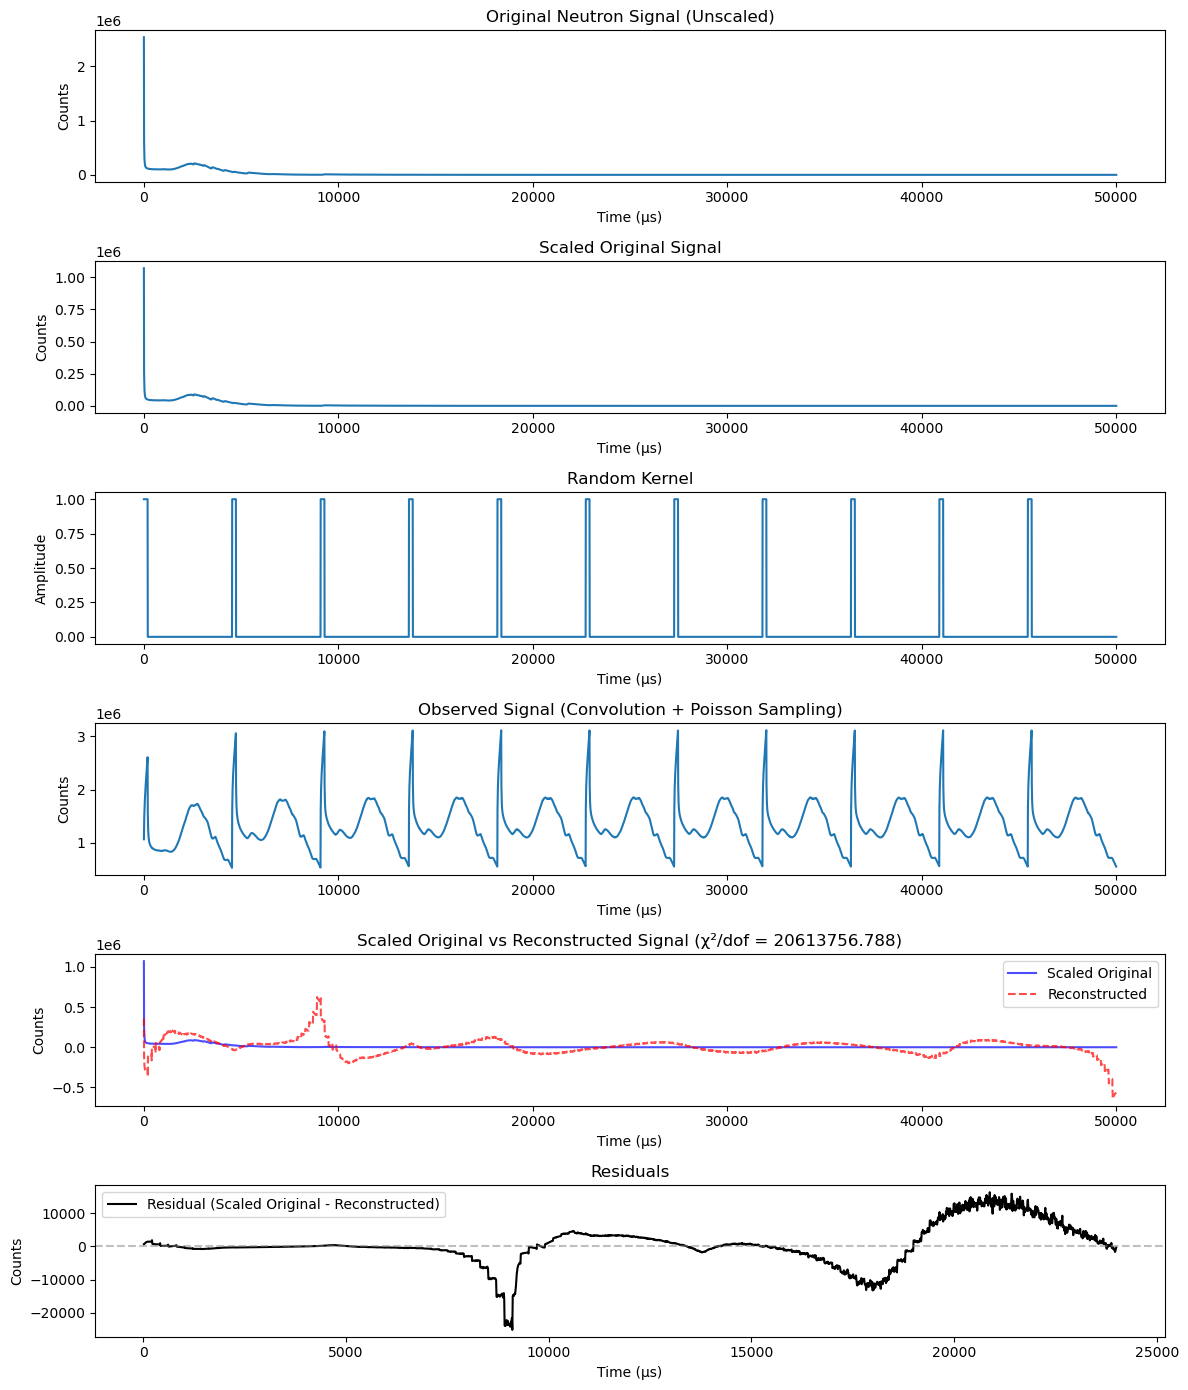

In [64]:
# t_signal, signal, errors, stacks = read_and_stack('iron_powder.csv')
# t_signal_ob, signal_ob, errors_ob, stacks_ob = read_and_stack('openbeam.csv')
t_signal, signal, errors, stacks = read_tof_data('iron_powder.csv')
t_signal_ob, signal_ob, errors_ob, stacks_ob = read_tof_data('openbeam.csv')
stacks1, signal1, errors1 = prepare_full_frame(t_signal, signal, errors, stacks, max_stack=5000)
stacks_ob1, signal_ob1, errors_ob1 = prepare_full_frame(t_signal_ob, signal_ob, errors_ob, stacks_ob, max_stack=5000)
saraf_irad_time = 24 # time in hours
frequency = 20 # frequency in herz
n_pulses = 11 # number of pulses
pulse_duration = 200 # pulse duration in usec
window_size=len(signal1)*10#50000
scaling_factor = (1e6/5e6) * (saraf_irad_time/0.5) * (frequency*n_pulses*pulse_duration*1e-6)
scaled_signal = signal1 * scaling_factor
scaled_ob = signal_ob1 * scaling_factor
t_kernel, kernel = generate_simple_kernel(n_pulses=n_pulses, pulse_duration=pulse_duration, window_size=window_size)
# t_kernel, kernel = generate_kernel(n_pulses=n_pulses, pulse_duration=pulse_duration, window_size=window_size)
# Apply Wiener deconvolution to the signal
print(stacks1)
observed_poisson, reconstructed = apply_filter(
    scaled_signal,
    kernel,
    # stats_fraction=1,
    noise_power=0.05
)
# Apply Wiener deconvolution to the signal
observed_poisson_ob, reconstructed_ob = apply_filter(
    scaled_ob,
    kernel,
    # stats_fraction=1,
    noise_power=0.05
)

# Calculate chi-squared statistics
chi2, chi2_per_dof = chi2_like_analysis1(
    scaled_signal,
    reconstructed,
    np.sqrt(scaled_signal),
    1100,
    n_pulses
)

length = 50000
plot_analysis(
    stacks1[:length]*10,
    signal1[:length],
    scaled_signal[:length],
    t_kernel[:length],
    kernel[:length],
    observed_poisson[:length],
    reconstructed[:length],
    (scaled_signal[:length] - reconstructed[:length])/np.sqrt(scaled_signal[:length]),
    chi2_per_dof
)

In [20]:
# Read the ToF data from a CSV file
# t_signal, signal, errors, stacks = read_tof_data('iron_powder.csv', threshold=40)
# t_signal_ob, signal_ob, errors_ob, stacks_ob = read_tof_data('openbeam.csv', threshold=40)

# t_signal, signal, errors, stacks = read_and_stack('iron_powder.csv')
# t_signal_ob, signal_ob, errors_ob, stacks_ob = read_and_stack('openbeam.csv')

In [5]:
t_signal, signal, errors, stacks = read_and_stack('iron_powder.csv')
t_signal_ob, signal_ob, errors_ob, stacks_ob = read_and_stack('openbeam.csv')

In [ ]:
saraf_irad_time = 24 # time in hours
frequency = 20 # frequency in herz
n_pulses = 10 # number of pulses
pulse_duration = 100 # pulse duration in usec
window_size=50000
scaling_factor = (1e6/5e6) * (saraf_irad_time/0.5) * (frequency*n_pulses*pulse_duration*1e-6)
scaled_signal = signal1 * scaling_factor
scaled_ob = signal_ob1 * scaling_factor
t_kernel, kernel = generate_simple_kernel(n_pulses=n_pulses, pulse_duration=pulse_duration, window_size=window_size)

# Apply Wiener deconvolution to the signal
observed_poisson, reconstructed = apply_filter(
    scaled_signal,
    kernel,
    # stats_fraction=1,
    noise_power=0.05
)

# Apply Wiener deconvolution to the signal
observed_poisson_ob, reconstructed_ob = apply_filter(
    scaled_ob,
    kernel,
    # stats_fraction=1,
    noise_power=0.05
)

In [ ]:
write_data(stacks1,reconstructed,np.sqrt(reconstructed),filepath='iron_powder1.csv')
write_data(stacks_ob1,reconstructed_ob,np.sqrt(reconstructed_ob),filepath='openbeam1.csv')

In [ ]:
saraf_irad_time = 24 # time in hours
frequency = 20 # frequency in herz
n_pulses = 10 # number of pulses
pulse_duration = 100 # pulse duration in usec
window_size=45000
scaling_factor = (1e6/5e6) * (saraf_irad_time/0.5) * (frequency*n_pulses*pulse_duration*1e-6)
scaled_signal = signal1 * scaling_factor
scaled_ob = signal_ob1 * scaling_factor
t_kernel, kernel = generate_simple_kernel(n_pulses=n_pulses, pulse_duration=pulse_duration, window_size=window_size)

# Apply Wiener deconvolution to the signal
observed_poisson, reconstructed = apply_filter(
    scaled_signal,
    kernel,
    # stats_fraction=1,
    noise_power=0.05
)

# Apply Wiener deconvolution to the signal
observed_poisson_ob, reconstructed_ob = apply_filter(
    scaled_ob,
    kernel,
    # stats_fraction=1,
    noise_power=0.05
)

In [ ]:
def write_data(stack,signal,error,filepath=''):
    df=pd.DataFrame()
    df['stack']=stack
    signal[signal<0]=0
    df['signal']=np.round(signal,3)
    error[error==np.isnan(error)]=0
    df['error']=np.round(error,3)
    
    df.to_csv(filepath,sep=',')

In [16]:
write_data(stacks1,reconstructed,np.sqrt(reconstructed),filepath='iron_powder1.csv')
write_data(stacks_ob1,reconstructed_ob,np.sqrt(reconstructed_ob),filepath='openbeam1.csv')

0

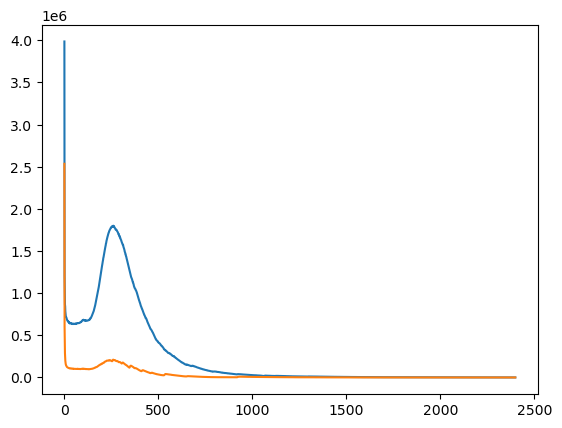

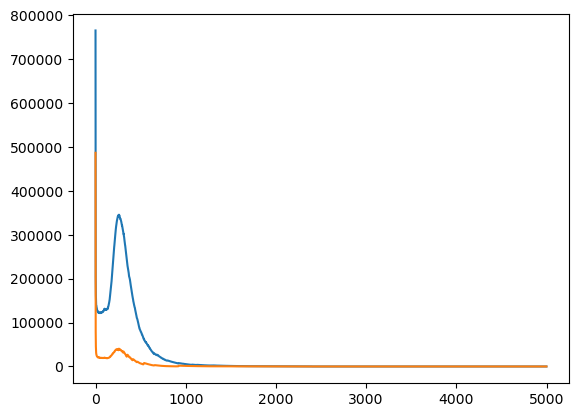

In [21]:
plt.plot(signal_ob)
plt.plot(signal)
plt.figure()
plt.plot(scaled_ob)
plt.plot(scaled_signal)
# plt.plot(reconstructed)

# plt.ylim(- 0.2,0.2)


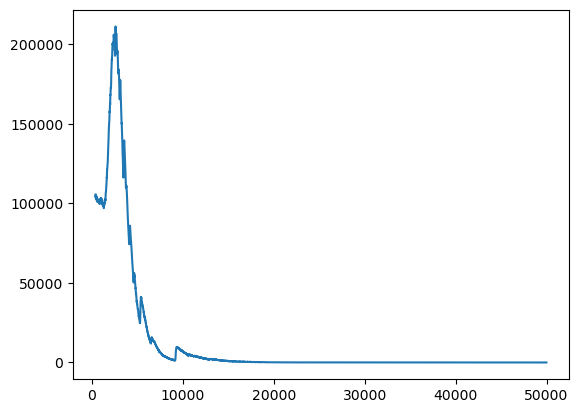

In [153]:
# print(signal)
plt.plot(t_signal,signal)
# t_signal[-1]
# print(signal)
